<a href="https://colab.research.google.com/github/KarthikSaravanakumarM56/24ADI003-24BAD056/blob/main/Scenario3_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 3 - Random Forest
### Predicting Income (>50K or <=50K)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv("income_random_forest.csv")
print(df.shape)
df.head()

(120, 5)


,Age,EducationYears,HoursPerWeek,Experience,Income
0,37,12,44,12,0
1,46,19,58,33,1
2,53,10,54,24,0
3,46,11,22,6,0
4,36,17,56,3,1


In [5]:
X = df.drop("Income", axis=1)
y = df["Income"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Train Random Forest with 100 trees
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest Accuracy (100 trees): {rf_acc:.4f}")

Random Forest Accuracy (100 trees): 1.0000


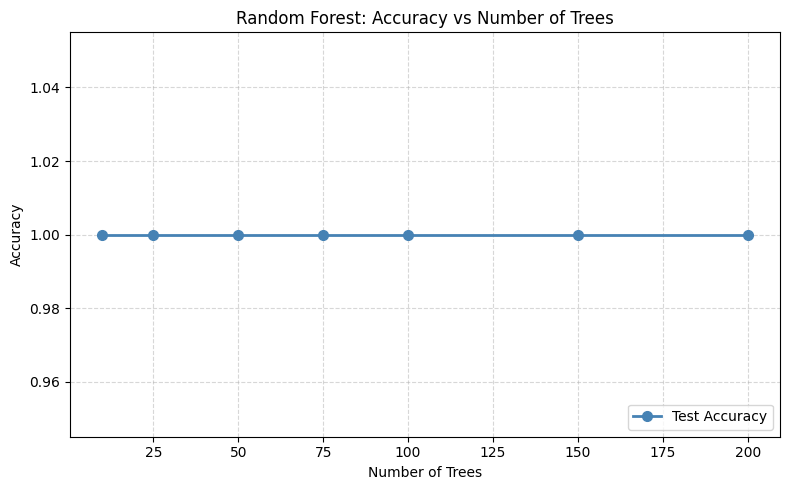

In [7]:
# Accuracy vs Number of Trees
tree_counts = [10, 25, 50, 75, 100, 150, 200]
accuracies = []

for n in tree_counts:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(tree_counts, accuracies, marker="o", color="steelblue", linewidth=2,
         markersize=7, label="Test Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest: Accuracy vs Number of Trees")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("scenario3_acc_trees.png", dpi=100)
plt.show()

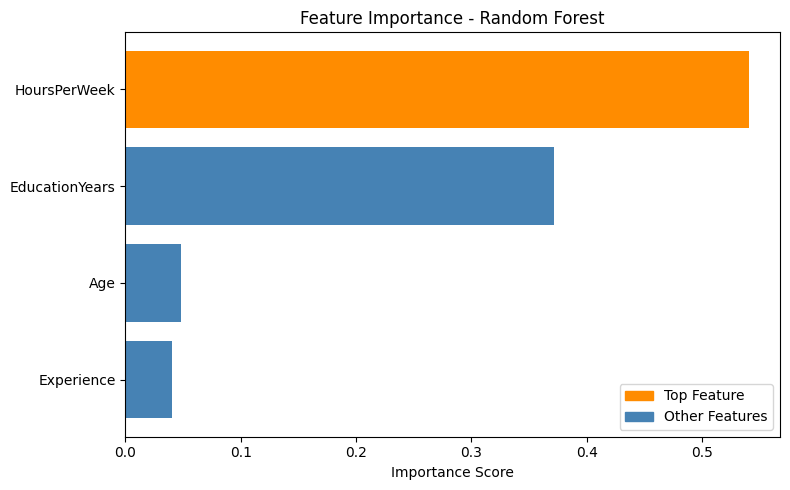

In [8]:
# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = ["darkorange" if v == feat_imp.max() else "steelblue" for v in feat_imp]
plt.barh(feat_imp.index, feat_imp.values, color=colors)
plt.xlabel("Importance Score")
plt.title("Feature Importance - Random Forest")
import matplotlib.patches as mpatches
top = mpatches.Patch(color="darkorange", label="Top Feature")
rest = mpatches.Patch(color="steelblue", label="Other Features")
plt.legend(handles=[top, rest], loc="lower right")
plt.tight_layout()
plt.savefig("scenario3_feat_imp.png", dpi=100)
plt.show()